<div dir="rtl" style="text-align: right;">

# LLM-as-a-Judge: ارزیابی خودکار پاسخ‌های RAG

این نوت‌بوک خروجی `run_validation.ipynb` (فایل `validation_results.json`) را می‌خواند و هر پاسخ را با یک **مدل داور مستقل** (متفاوت از مدلی که پاسخ را تولید کرده) بر اساس شواهد واقعی نظرات ارزیابی می‌کند.

سه معیار داوری می‌شود:
- **Groundedness** — آیا پاسخ فقط بر اساس شواهد ارائه‌شده است و چیزی اضافه (Hallucination) ندارد؟
- **Relevance** — آیا پاسخ واقعاً به سؤال پرسیده‌شده پاسخ می‌دهد؟
- **Completeness** — آیا پاسخ نکات مهم موجود در شواهد را پوشش می‌دهد؟

این نسخه علاوه بر موارد قبلی، **مصرف توکن و هزینه را ردیابی می‌کند** و یک **سقف بودجه (Budget Guard)** دارد که قبل از رسیدن به آن، اجرای داوری را متوقف می‌کند.

> ⚠️ **نکته درباره‌ی نرخ‌های هزینه:** مقادیر `PRICING_PER_1M_TOKENS` بر مبنای قیمت‌گذاری عمومی OpenAI هستند و صرفاً Placeholder‌اند — نرخ واقعی Metis AI ممکن است متفاوت باشد؛ قبل از تصمیم واقعی، این مقادیر را با نرخ دقیق حساب خودتان جایگزین کنید.


</div>

<div dir="rtl" style="text-align: right;">

## بخش ۱ — نصب و ایمپورت

</div>

In [1]:
import os
import json
import time
import re

import requests
import pandas as pd


<div dir="rtl" style="text-align: right;">

## بخش ۲ — تنظیمات (Config)

</div>

In [ ]:
INPUT_FILE = "validation_results.json"        # خروجی run_validation.ipynb
OUTPUT_JSON = "judge_results.json"
OUTPUT_CSV = "judge_manual_review.csv"

API_URL = "https://api.metisai.ir/openai/v1/chat/completions"
API_KEY = os.environ.get("METIS_API_KEY", "****")

# مدل داور عمداً متفاوت از مدل تولیدکننده‌ی پاسخ (gpt-4o-mini) انتخاب شده
# تا از سوگیری «مدل، پاسخ خودش را قضاوت کند» جلوگیری شود.
# اگر این مدل در حساب شما در دسترس نیست، لیست مدل‌ها را با همان
# سلول تست اتصال در run_validation.ipynb بررسی و این مقدار را عوض کنید.
GENERATOR_MODEL = "gpt-4o-mini"   # مدلی که پاسخ‌های اصلی را تولید کرده
JUDGE_MODEL = "gpt-4o"            # مدل داور

VALID_VERDICTS = {"pass", "fail"}

# ------------------------------------------------------------
# قیمت‌گذاری و بودجه (Cost Tracking & Budget Guard)
# ------------------------------------------------------------

# نرخ‌ها بر اساس قیمت‌گذاری عمومی OpenAI برای هر ۱ میلیون توکن است.
# این‌ها Placeholder هستند — قبل از اجرای واقعی با نرخ دقیق حساب
# Metis AI خودتان جایگزین کنید.
PRICING_PER_1M_TOKENS = {
    "gpt-4o-mini": {"input": 0.15, "output": 0.60},
    "gpt-4o": {"input": 2.50, "output": 10.00},
}

MAX_BUDGET_USD = 5.0  # سقف هزینه‌ی مجاز برای کل اجرای این نوت‌بوک (فقط هزینه‌ی داوری)

total_prompt_tokens = 0
total_completion_tokens = 0
total_cost_usd = 0.0


def estimate_cost(model, prompt_tokens, completion_tokens):
    rates = PRICING_PER_1M_TOKENS.get(model)
    if rates is None:
        return 0.0
    input_cost = (prompt_tokens / 1_000_000) * rates["input"]
    output_cost = (completion_tokens / 1_000_000) * rates["output"]
    return input_cost + output_cost


<div dir="rtl" style="text-align: right;">

## بخش ۳ — بارگذاری نتایج تولیدشده توسط مدل اول

</div>

In [3]:
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    generation_results = json.load(f)

# فقط مواردی که پاسخ موفق داشته‌اند را داوری می‌کنیم (نه خطاهای API)
generation_results = [r for r in generation_results if r.get("answer")]

print("Results to judge:", len(generation_results))


Results to judge: 191


<div dir="rtl" style="text-align: right;">

## بخش ۴ — ساخت Prompt داوری (Judge Prompt)

</div>

In [4]:
def build_judge_prompt(item):
    product_title = item["product_title"]
    question = item["question"]
    answer = item["answer"]

    evidence_text = []
    for evidence in item["evidence"]:
        evidence_text.append(f"""
COMMENT ID: {evidence["comment_id"]}
Title: {evidence["title"]}
Body: {evidence["body"]}
Advantages: {evidence["advantages"]}
Disadvantages: {evidence["disadvantages"]}
""")
    evidence_text = "\n".join(evidence_text)

    prompt = f"""
شما یک داور مستقل و دقیق هستید که کیفیت پاسخ یک دستیار هوش مصنوعی را
درباره‌ی نظرات کاربران یک محصول ارزیابی می‌کنید.

محصول:
{product_title}

سؤال:
{question}

شواهد (نظرات واقعی کاربران که در اختیار دستیار قرار گرفته بود):
{evidence_text}

پاسخ دستیار:
{answer}

پاسخ را بر اساس سه معیار زیر از ۱ تا ۵ نمره بده:

1. groundedness: آیا پاسخ فقط از اطلاعات موجود در شواهد بالا استفاده کرده
   و هیچ ادعای بی‌اساس یا ساختگی (hallucination) ندارد؟
2. relevance: آیا پاسخ دقیقاً به همین سؤال پاسخ می‌دهد؟
3. completeness: آیا پاسخ نکات مهم و پرتکرار موجود در شواهد را پوشش می‌دهد؟

سپس یک قضاوت نهایی "pass" یا "fail" بده (fail یعنی حداقل یکی از
معیارها به‌طور جدی مشکل دارد، به‌خصوص groundedness).

فقط و فقط یک شیء JSON با دقیقاً همین ساختار برگردان، بدون هیچ توضیح اضافه:

{{
  "groundedness": <1-5>,
  "relevance": <1-5>,
  "completeness": <1-5>,
  "verdict": "pass" یا "fail",
  "reasoning": "توضیح کوتاه یک یا دو جمله‌ای برای این قضاوت"
}}
"""
    return prompt


<div dir="rtl" style="text-align: right;">

## بخش ۵ — تابع فراخوانی مدل داور

</div>

In [5]:
def call_judge(prompt):
    headers = {"Content-Type": "application/json"}
    if API_KEY:
        headers["Authorization"] = f"Bearer {API_KEY}"

    payload = {
        "model": JUDGE_MODEL,
        "messages": [
            {
                "role": "system",
                "content": (
                    "You are a strict, independent evaluator. "
                    "Always respond with valid JSON only, no extra text."
                ),
            },
            {"role": "user", "content": prompt},
        ],
        "temperature": 0,
    }

    start_time = time.perf_counter()
    response = requests.post(API_URL, headers=headers, json=payload, timeout=300)
    latency = time.perf_counter() - start_time

    response.raise_for_status()
    data = response.json()
    content = data["choices"][0]["message"]["content"]

    usage = data.get("usage", {})
    prompt_tokens = usage.get("prompt_tokens", 0)
    completion_tokens = usage.get("completion_tokens", 0)

    return content, latency, prompt_tokens, completion_tokens


<div dir="rtl" style="text-align: right;">

## بخش ۶ — تابع استخراج امن JSON از پاسخ داور

</div>

In [ ]:
def parse_judge_response(raw_text):

    text = raw_text.strip()
    text = re.sub(r"^```(json)?", "", text).strip()
    text = re.sub(r"```$", "", text).strip()

    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not match:
        raise ValueError(f"No JSON object found in judge response: {raw_text[:200]}")

    parsed = json.loads(match.group(0))

    required_keys = {"groundedness", "relevance", "completeness", "verdict", "reasoning"}
    if not required_keys.issubset(parsed.keys()):
        raise ValueError(f"Missing keys in judge response: {parsed}")

    if parsed["verdict"] not in VALID_VERDICTS:
        raise ValueError(f"Invalid verdict value: {parsed['verdict']}")

    return parsed


<div dir="rtl" style="text-align: right;">

## بخش ۷ — اجرای داوری روی همه‌ی پاسخ‌ها (با Budget Guard)

قبل از هر فراخوانی، هزینه‌ی تجمعی با `MAX_BUDGET_USD` مقایسه می‌شود. با رسیدن به سقف، حلقه بدون فراخوانی موارد باقی‌مانده متوقف می‌شود و آن موارد با verdict برابر `skipped_budget_limit` ثبت می‌شوند.

</div>

In [7]:
judged_results = []

for index, item in enumerate(generation_results, start=1):
    if total_cost_usd >= MAX_BUDGET_USD:
        print(
            f"\n🛑 Budget limit reached (${total_cost_usd:.4f} >= ${MAX_BUDGET_USD:.2f}). "
            f"Stopping before item {index}/{len(generation_results)}."
        )
        judged_results.append({
            "product_id": item["product_id"],
            "product_title": item["product_title"],
            "question": item["question"],
            "answer": item["answer"],
            "groundedness": None,
            "relevance": None,
            "completeness": None,
            "verdict": "skipped_budget_limit",
            "reasoning": "Stopped before judging: budget limit reached.",
            "judge_latency_seconds": None,
            "prompt_tokens": 0,
            "completion_tokens": 0,
            "cost_usd": 0.0,
            "evidence": item["evidence"],
        })
        continue

    print(f"[{index}/{len(generation_results)}] {item['product_title']} | {item['question']}")

    prompt = build_judge_prompt(item)

    try:
        raw_response, latency, prompt_tokens, completion_tokens = call_judge(prompt)
        scores = parse_judge_response(raw_response)

        call_cost = estimate_cost(JUDGE_MODEL, prompt_tokens, completion_tokens)
        total_prompt_tokens += prompt_tokens
        total_completion_tokens += completion_tokens
        total_cost_usd += call_cost

        judged_results.append({
            "product_id": item["product_id"],
            "product_title": item["product_title"],
            "question": item["question"],
            "answer": item["answer"],
            "groundedness": scores["groundedness"],
            "relevance": scores["relevance"],
            "completeness": scores["completeness"],
            "verdict": scores["verdict"],
            "reasoning": scores["reasoning"],
            "judge_latency_seconds": latency,
            "prompt_tokens": prompt_tokens,
            "completion_tokens": completion_tokens,
            "cost_usd": call_cost,
            "evidence": item["evidence"],
        })

        print(
            f"  -> verdict={scores['verdict']} | latency={latency:.2f}s "
            f"| tokens: {prompt_tokens}+{completion_tokens} | cost: ${call_cost:.4f} "
            f"| running total: ${total_cost_usd:.4f}"
        )

    except Exception as e:
        print("  ERROR:", str(e))
        judged_results.append({
            "product_id": item["product_id"],
            "product_title": item["product_title"],
            "question": item["question"],
            "answer": item["answer"],
            "groundedness": None,
            "relevance": None,
            "completeness": None,
            "verdict": "error",
            "reasoning": str(e),
            "judge_latency_seconds": None,
            "prompt_tokens": 0,
            "completion_tokens": 0,
            "cost_usd": 0.0,
            "evidence": item["evidence"],
        })


[1/191] برس مژه و ابرو کد BR01ABO | مردم بیشتر از چه چیزی در این محصول راضی بودند؟
  -> verdict=pass | latency=4.43s | tokens: 713+96 | cost: $0.0027 | running total: $0.0027
[2/191] برس مژه و ابرو کد BR01ABO | ایرادهای پرتکرار این محصول چیست؟
  -> verdict=pass | latency=5.01s | tokens: 642+84 | cost: $0.0024 | running total: $0.0052
[3/191] برس مژه و ابرو کد BR01ABO | خریداران درباره‌ی کیفیت این محصول چه گفته‌اند؟
  -> verdict=pass | latency=2.47s | tokens: 745+87 | cost: $0.0027 | running total: $0.0079
[4/191] برس مژه و ابرو کد BR01ABO | آیا با توجه به تجربه‌ی کاربران ارزش خرید دارد؟
  -> verdict=fail | latency=5.47s | tokens: 809+87 | cost: $0.0029 | running total: $0.0108
[5/191] پیلینگ صورت مدل Eli-74 | مردم بیشتر از چه چیزی در این محصول راضی بودند؟
  -> verdict=pass | latency=2.84s | tokens: 715+85 | cost: $0.0026 | running total: $0.0135
[6/191] پیلینگ صورت مدل Eli-74 | ایرادهای پرتکرار این محصول چیست؟
  -> verdict=pass | latency=2.90s | tokens: 629+84 | cost: $0.0024 | running

<div dir="rtl" style="text-align: right;">

## بخش ۸ — خلاصه‌ی مصرف توکن و هزینه‌ی داوری

</div>

In [8]:
print("=" * 40)
print(f"Total prompt tokens:     {total_prompt_tokens}")
print(f"Total completion tokens: {total_completion_tokens}")
print(f"Total tokens:            {total_prompt_tokens + total_completion_tokens}")
print(f"Estimated total cost:    ${total_cost_usd:.4f}")
print(f"Budget limit:            ${MAX_BUDGET_USD:.2f}")
print(f"Remaining budget:        ${MAX_BUDGET_USD - total_cost_usd:.4f}")
print("=" * 40)


Total prompt tokens:     68476
Total completion tokens: 7380
Total tokens:            75856
Estimated total cost:    $0.2450
Budget limit:            $5.00
Remaining budget:        $4.7550


<div dir="rtl" style="text-align: right;">

## بخش ۹ — ذخیره‌سازی نتایج خام داوری (JSON)

</div>

In [9]:
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(judged_results, f, ensure_ascii=False, indent=2)

print(f"Saved JSON: {OUTPUT_JSON}")


Saved JSON: judge_results.json


<div dir="rtl" style="text-align: right;">

## بخش ۱۰ — خلاصه‌ی آماری داوری

</div>

In [10]:
df_judged = pd.DataFrame(judged_results)

valid = df_judged[df_judged["verdict"] != "error"]

print("Total judged:", len(df_judged))
print("Errors during judging:", (df_judged["verdict"] == "error").sum())

print("\nVerdict distribution:")
print(valid["verdict"].value_counts())

print("\nAverage scores:")
print(valid[["groundedness", "relevance", "completeness"]].mean().round(2))


Total judged: 191
Errors during judging: 105

Verdict distribution:
verdict
pass    79
fail     7
Name: count, dtype: int64

Average scores:
groundedness    4.70
relevance       4.95
completeness    4.41
dtype: float64


<div dir="rtl" style="text-align: right;">

## بخش ۱۱ — نمودار توزیع نمرات
</div>

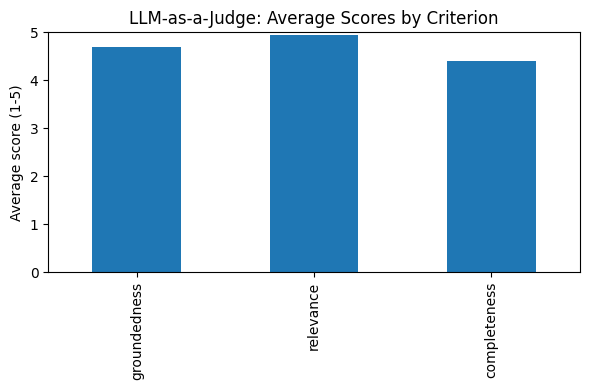

In [11]:
import matplotlib.pyplot as plt

score_columns = ["groundedness", "relevance", "completeness"]
mean_scores = valid[score_columns].mean()

plt.figure(figsize=(6, 4))
mean_scores.plot(kind="bar")
plt.ylim(0, 5)
plt.ylabel("Average score (1-5)")
plt.title("LLM-as-a-Judge: Average Scores by Criterion")
plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right;">

## بخش ۱۲ — ساخت CSV نهایی برای بررسی دستی

این جدول، سؤال/پاسخ/نمرات/هزینه/دلیل داوری را در کنار متن کامل شواهد قرار می‌دهد تا موارد `fail` یا نمره‌ی پایین به‌سرعت برای بازبینی انسانی پیدا شوند.
</div>

In [12]:
csv_rows = []

for result in judged_results:
    evidence_texts = []
    for evidence in result["evidence"]:
        evidence_texts.append(
            f"[COMMENT ID: {evidence['comment_id']}]\n"
            f"Title: {evidence['title']}\n"
            f"Body: {evidence['body']}"
        )

    csv_rows.append({
        "product_id": result["product_id"],
        "product_title": result["product_title"],
        "question": result["question"],
        "answer": result["answer"],
        "groundedness": result["groundedness"],
        "relevance": result["relevance"],
        "completeness": result["completeness"],
        "verdict": result["verdict"],
        "reasoning": result["reasoning"],
        "prompt_tokens": result.get("prompt_tokens", 0),
        "completion_tokens": result.get("completion_tokens", 0),
        "cost_usd": result.get("cost_usd", 0.0),
        "evidence_comments": "\n\n".join(evidence_texts),
    })

df_review = pd.DataFrame(csv_rows)
df_review = df_review.sort_values(["verdict", "groundedness"], ascending=[False, True])
df_review.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print(f"Saved: {OUTPUT_CSV}")
print("\nLowest-scoring / failed items to review first:")
display(df_review.head(10))


Saved: judge_manual_review.csv

Lowest-scoring / failed items to review first:


,product_id,product_title,question,answer,groundedness,relevance,completeness,verdict,reasoning,prompt_tokens,completion_tokens,cost_usd,evidence_comments
31,82098,شامپو تقویت کننده و ضد ریزش مو فولیکا حجم 200 ...,آیا با توجه به تجربه‌ی کاربران ارزش خرید دارد؟,با توجه به نظرات کاربران، به نظر می‌رسد که شام...,3.0,5.0,4.0,pass,پاسخ به سؤال مرتبط است و به نظرات کاربران اشار...,807,80,0.002818,[COMMENT ID: 53311300]\nTitle: \nBody: ارزش خر...
0,4095187,برس مژه و ابرو کد BR01ABO,مردم بیشتر از چه چیزی در این محصول راضی بودند؟,مردم بیشتر از کیفیت و ظاهر برس مژه و ابرو راضی...,4.0,5.0,4.0,pass,پاسخ به‌طور کلی بر اساس شواهد موجود است، اما ب...,713,96,0.002743,[COMMENT ID: 53923364]\nTitle: \nBody: عالی بو...
8,3331597,برس ریمل مدل LM02 مجموعه 2 عددی,مردم بیشتر از چه چیزی در این محصول راضی بودند؟,مردم بیشتر از کیفیت و قیمت مناسب این محصول راض...,4.0,5.0,4.0,pass,پاسخ به‌طور کلی بر اساس شواهد موجود است و به س...,724,88,0.002690,[COMMENT ID: 37601030]\nTitle: \nBody: محصول خ...
15,2156856,استیک ضد تعریق زنانه لیدی اسپید مدل invisible ...,آیا با توجه به تجربه‌ی کاربران ارزش خرید دارد؟,با توجه به نظرات کاربران، به نظر می‌رسد که است...,4.0,5.0,4.0,pass,پاسخ به‌طور کلی بر اساس شواهد ارائه شده است، ا...,789,114,0.003112,[COMMENT ID: 41131718]\nTitle: \nBody: خیلی عا...
19,2156856,استیک ضد تعریق زنانه لیدی اسپید مدل invisible ...,آیا با توجه به تجربه‌ی کاربران ارزش خرید دارد؟,با توجه به نظرات کاربران، به نظر می‌رسد که است...,4.0,5.0,4.0,pass,پاسخ به خوبی به سؤال پاسخ می‌دهد و بیشتر نظرات...,800,88,0.002880,[COMMENT ID: 41131718]\nTitle: \nBody: خیلی عا...
33,82098,شامپو تقویت کننده و ضد ریزش مو فولیکا حجم 200 ...,ایرادهای پرتکرار این محصول چیست؟,بر اساس نظرات کاربران، ایرادهای پرتکرار این مح...,4.0,5.0,3.0,pass,پاسخ به خوبی به سؤال پاسخ می‌دهد و از شواهد مو...,825,85,0.002913,[COMMENT ID: 53421991]\nTitle: بد نیست\nBody: ...
38,4012333,تونر پاک کننده صورت لافارر مدل مولتی اکتیو منا...,آیا با توجه به تجربه‌ی کاربران ارزش خرید دارد؟,با توجه به نظرات کاربران، به نظر می‌رسد که تون...,4.0,5.0,4.0,pass,پاسخ به خوبی به سؤال پاسخ می‌دهد و بیشتر نظرات...,942,79,0.003145,[COMMENT ID: 54333975]\nTitle: خوبه\nBody: خوب...
53,4012333,تونر پاک کننده صورت لافارر مدل مولتی اکتیو منا...,خریداران درباره‌ی کیفیت این محصول چه گفته‌اند؟,خریداران درباره‌ی کیفیت تونر پاک کننده صورت لا...,4.0,5.0,4.0,pass,پاسخ به طور کلی بر اساس شواهد ارائه شده است و ...,855,86,0.002998,[COMMENT ID: 54177466]\nTitle: \nBody: کیفیتش ...
54,4012333,تونر پاک کننده صورت لافارر مدل مولتی اکتیو منا...,آیا با توجه به تجربه‌ی کاربران ارزش خرید دارد؟,با توجه به نظرات کاربران، به نظر می‌رسد که تون...,4.0,5.0,4.0,pass,پاسخ به خوبی به سؤال پاسخ می‌دهد و بیشتر نظرات...,962,86,0.003265,[COMMENT ID: 54333975]\nTitle: خوبه\nBody: خوب...
1,4095187,برس مژه و ابرو کد BR01ABO,ایرادهای پرتکرار این محصول چیست؟,شواهد کافی در نظرات ارائه‌شده وجود ندارد تا ای...,5.0,5.0,5.0,pass,پاسخ دستیار به‌طور کامل بر اساس شواهد موجود اس...,642,84,0.002445,[COMMENT ID: 46353115]\nTitle: برس مژه و ابرو\...
